# DFNN from scratch (NumPy)

**Objective:** Implements deep feedforward neural network (DFNN) from scratch using only Python + NumPy. Train it on `make_moons`, visualize loss and decision boundary, and provide evaluation & discussion.

**This notebook contains**
- Activation functions & derivatives
- Numerically-stable Binary Cross-Entropy loss
- "DeepNeuralNetwork" class (vectorized)
- Data generation & visualization
- Model training, loss plot, decision boundary
- Evaluation, gradient check, saving & download tips


In [3]:
!pip install -q scikit-learn seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.metrics import confusion_matrix
from IPython.display import display, FileLink
from google.colab import files
import time

%matplotlib inline
np.random.seed(42)

print("Setup complete. Numpy version:", np.__version__)


Setup complete. Numpy version: 2.0.2


**Implement**
- sigmoid(z) and derivative (using a = sigmoid(z))
- relu(z) and derivative (using z)
- tanh(z) and derivative (using a = tanh(z))

**Inshort**
- Use ReLU in most hidden layers (fast, simple).
- Use sigmoid in final output for binary classification.
- Use tanh if you want zero-centered activations.


In [17]:
def sigmoid(z):
    """Elementwise sigmoid"""
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative_from_a(a):
    """Derivative of sigmoid given activation a = sigmoid(z)"""
    return a * (1 - a)

def relu(z):
    """ReLU activation"""
    return np.maximum(0, z)

def relu_derivative(z):
    """Derivative of ReLU wrt z"""
    dz = np.zeros_like(z)
    dz[z > 0] = 1.0
    return dz

def tanh(z):
    return np.tanh(z)

def tanh_derivative_from_a(a):
    return 1.0 - np.power(a, 2)

# quick sanity
z = np.array([-2., -1., 0., 1., 2.])
print("sigmoid:", sigmoid(z))
print("relu:", relu(z))
print("tanh:", tanh(z))


sigmoid: [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
relu: [0. 0. 0. 1. 2.]
tanh: [-0.96402758 -0.76159416  0.          0.76159416  0.96402758]


Binary Cross-Entropy (BCE) loss (mean over batch):
L = -1/m * sum( y*log(y_hat) + (1-y)*log(1-y_hat) )
We clip y_hat to [eps, 1-eps] to avoid log(0).
Also implement derivative dL/dA_last for vectorized batches.


In [5]:
def binary_cross_entropy_loss(y_hat, y, eps=1e-8):
    """
    y_hat: (1, m) predicted probabilities
    y: (1, m) true binary labels
    returns: scalar mean loss
    """
    y_hat_clipped = np.clip(y_hat, eps, 1 - eps)
    m = y.shape[1]
    loss = - (1.0 / m) * np.sum(y * np.log(y_hat_clipped) + (1 - y) * np.log(1 - y_hat_clipped))
    return loss

def bce_derivative(y_hat, y, eps=1e-8):
    """dL/dA_last, shape (1,m)"""
    y_hat_clipped = np.clip(y_hat, eps, 1 - eps)
    return - (np.divide(y, y_hat_clipped) - np.divide(1 - y, 1 - y_hat_clipped)) / y.shape[1]


**Features**
- __init__(layer_dims, activation_funcs, seed=42, init='he'/'xavier'/'random')
- forward_pass(X) -> returns A_last, caches (Z and A per layer)
- backward_pass(X, y) -> returns grads (dW, db)
- update_parameters(grads, lr, l2_lambda=0.0)
- compute_loss_and_accuracy(X, y)
- train(X, y, epochs, learning_rate, batch_size=None, print_loss=True)
- predict(X, threshold=0.5)
Utility internal funcs: _linear_forward, _linear_activation_forward, _linear_backward, _activation_backward
All computations are vectorized (no loops over training examples).
Shapes conventions:
- W[l]: (units_l, units_prev)
- b[l]: (units_l, 1)
- A[l]: (units_l, m)
- X: (n_x, m)


In [6]:
class DeepNeuralNetwork:
    def __init__(self, layer_dims, activation_funcs, seed=42, init='he'):
        """
        layer_dims: e.g. [2, 20, 10, 1]
        activation_funcs: list of strings of length L (e.g. ['relu','relu','sigmoid'])
        init: 'he' (recommended for ReLU), 'xavier' (sigmoid/tanh), 'random'
        """
        np.random.seed(seed)
        self.layer_dims = layer_dims
        self.L = len(layer_dims) - 1
        assert len(activation_funcs) == self.L, "activation_funcs length must equal number of layers"
        self.activation_funcs = activation_funcs
        self.params = {}
        for l in range(1, self.L + 1):
            in_dim = layer_dims[l-1]
            out_dim = layer_dims[l]
            if init == 'he':
                self.params['W' + str(l)] = np.random.randn(out_dim, in_dim) * np.sqrt(2.0 / in_dim)
            elif init == 'xavier':
                self.params['W' + str(l)] = np.random.randn(out_dim, in_dim) * np.sqrt(1.0 / in_dim)
            else:
                self.params['W' + str(l)] = np.random.randn(out_dim, in_dim) * 0.01
            self.params['b' + str(l)] = np.zeros((out_dim, 1))
        self.caches = {}

    # Activation dispatch
    def _activate(self, Z, func):
        if func == 'relu':
            return relu(Z)
        elif func == 'sigmoid':
            return sigmoid(Z)
        elif func == 'tanh':
            return tanh(Z)
        else:
            raise ValueError("Unknown activation " + str(func))

    def _activation_derivative(self, Z, A, func):
        if func == 'relu':
            return relu_derivative(Z)
        elif func == 'sigmoid':
            return sigmoid_derivative_from_a(A)
        elif func == 'tanh':
            return tanh_derivative_from_a(A)
        else:
            raise ValueError("Unknown activation " + str(func))

    # Forward helpers
    def _linear_forward(self, A_prev, W, b):
        # A_prev: (units_prev, m), W: (units, units_prev), b: (units,1)
        Z = W.dot(A_prev) + b
        return Z

    def _linear_activation_forward(self, A_prev, W, b, func):
        Z = self._linear_forward(A_prev, W, b)
        A = self._activate(Z, func)
        return Z, A

    def forward_pass(self, X):
        """
        X: (n_x, m)
        returns: A_last, caches stored in self.caches
        caches: A0..AL and Z1..ZL
        """
        caches = {}
        A = X
        caches['A0'] = A
        for l in range(1, self.L + 1):
            W = self.params['W' + str(l)]
            b = self.params['b' + str(l)]
            Z, A = self._linear_activation_forward(A, W, b, self.activation_funcs[l-1])
            caches['Z' + str(l)] = Z
            caches['A' + str(l)] = A
        self.caches = caches
        return A, caches

    # Backward helpers
    def _linear_backward(self, dZ, A_prev, W, m):
        # dZ: (units, m), A_prev: (units_prev, m)
        dW = (1.0 / m) * dZ.dot(A_prev.T)        # (units, units_prev)
        db = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)  # (units, 1)
        dA_prev = W.T.dot(dZ)                   # (units_prev, m)
        return dA_prev, dW, db

    def _activation_backward(self, dA, Z, A, func):
        dZ = dA * self._activation_derivative(Z, A, func)
        return dZ

    def backward_pass(self, X, y):
        """
        X: (n_x, m), y: (1,m)
        returns grads dict {dW1, db1, ..., dWL, dbL}
        """
        grads = {}
        m = X.shape[1]
        A_L = self.caches['A' + str(self.L)]
        dA = bce_derivative(A_L, y)  # (1,m)
        for l in reversed(range(1, self.L + 1)):
            A_prev = self.caches['A' + str(l-1)]
            Z = self.caches['Z' + str(l)]
            A = self.caches['A' + str(l)]
            dZ = self._activation_backward(dA, Z, A, self.activation_funcs[l-1])
            dA_prev, dW, db = self._linear_backward(dZ, A_prev, self.params['W' + str(l)], m)
            grads['dW' + str(l)] = dW
            grads['db' + str(l)] = db
            dA = dA_prev
        return grads

    def update_parameters(self, grads, learning_rate=0.01, l2_lambda=0.0):
        """
        Update params in-place. l2_lambda applies weight decay to W.
        """
        for l in range(1, self.L + 1):
            if l2_lambda != 0:
                self.params['W' + str(l)] -= learning_rate * (grads['dW' + str(l)] + l2_lambda * self.params['W' + str(l)])
            else:
                self.params['W' + str(l)] -= learning_rate * grads['dW' + str(l)]
            self.params['b' + str(l)] -= learning_rate * grads['db' + str(l)]

    def compute_loss_and_accuracy(self, X, y):
        A_L, _ = self.forward_pass(X)
        loss = binary_cross_entropy_loss(A_L, y)
        preds = (A_L >= 0.5).astype(int)
        acc = np.mean(preds == y)
        return loss, acc

    def train(self, X, y, epochs=1000, learning_rate=0.01, batch_size=None, print_loss=True, l2_lambda=0.0):
        """
        Train network. If batch_size=None -> full-batch. Else mini-batch with given batch_size.
        Returns: list of losses per epoch.
        """
        m = X.shape[1]
        losses = []
        for epoch in range(1, epochs + 1):
            if batch_size is None:
                A_L, _ = self.forward_pass(X)
                loss = binary_cross_entropy_loss(A_L, y)
                grads = self.backward_pass(X, y)
                self.update_parameters(grads, learning_rate, l2_lambda)
            else:
                perm = np.random.permutation(m)
                X_shuf = X[:, perm]
                y_shuf = y[:, perm]
                loss_accum = 0.0
                for i in range(0, m, batch_size):
                    X_batch = X_shuf[:, i:i+batch_size]
                    y_batch = y_shuf[:, i:i+batch_size]
                    A_L, _ = self.forward_pass(X_batch)
                    loss_accum += binary_cross_entropy_loss(A_L, y_batch) * X_batch.shape[1]
                    grads = self.backward_pass(X_batch, y_batch)
                    self.update_parameters(grads, learning_rate, l2_lambda)
                loss = loss_accum / m
            losses.append(loss)
            if print_loss and (epoch % max(1, epochs//10) == 0 or epoch == 1):
                acc = np.mean((self.caches['A' + str(self.L)] >= 0.5).astype(int) == y)
                print(f"Epoch {epoch}/{epochs} - loss: {loss:.6f} - acc: {acc:.4f}")
        return losses

    def predict(self, X, threshold=0.5):
        A_L, _ = self.forward_pass(X)
        probs = A_L
        preds = (probs >= threshold).astype(int)
        return preds, probs


Create make_moons with 200 samples and noise=0.2. For our code:
- X: shape (2, m)
- y: shape (1, m)
Plot scatter with color by class.


X.shape: (2, 200) y.shape: (1, 200)


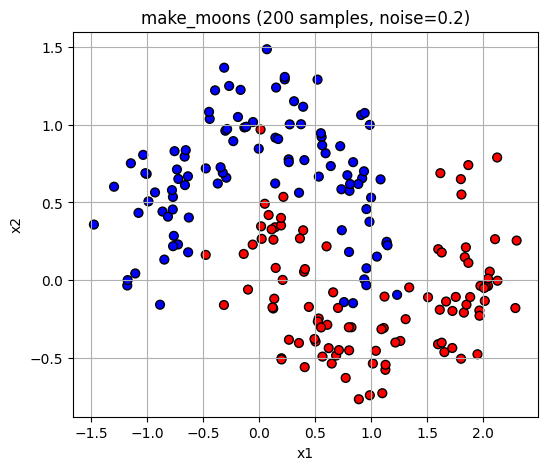

In [7]:
X_raw, y_raw = make_moons(n_samples=200, noise=0.2, random_state=42)
X = X_raw.T         # (2, m)
y = y_raw.reshape(1, -1)  # (1, m)
print("X.shape:", X.shape, "y.shape:", y.shape)

plt.figure(figsize=(6,5))
plt.scatter(X[0, :], X[1, :], c=y.ravel(), cmap='bwr', edgecolor='k', s=40)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('make_moons (200 samples, noise=0.2)')
plt.grid(True)
plt.show()


Example architecture: [2, 20, 10, 1] with ['relu','relu','sigmoid'].
Train for e.g., epochs=1000, learning_rate=0.05 (tweak if unstable). batch_size=None => full-batch.


In [8]:
layer_dims = [2, 20, 10, 1]
activations = ['relu', 'relu', 'sigmoid']
model = DeepNeuralNetwork(layer_dims, activations, seed=42, init='he')

epochs = 1000
learning_rate = 0.05
batch_size = None   # 32 for mini-batch
start = time.time()
losses = model.train(X, y, epochs=epochs, learning_rate=learning_rate, batch_size=batch_size, print_loss=True, l2_lambda=0.0)
end = time.time()
print(f"Training time: {end - start:.2f} seconds")


Epoch 1/1000 - loss: 0.694439 - acc: 0.5000
Epoch 100/1000 - loss: 0.679620 - acc: 0.5400
Epoch 200/1000 - loss: 0.665651 - acc: 0.6300
Epoch 300/1000 - loss: 0.652632 - acc: 0.6550
Epoch 400/1000 - loss: 0.640413 - acc: 0.6500
Epoch 500/1000 - loss: 0.628994 - acc: 0.6650
Epoch 600/1000 - loss: 0.618311 - acc: 0.6700
Epoch 700/1000 - loss: 0.608269 - acc: 0.6800
Epoch 800/1000 - loss: 0.598805 - acc: 0.6800
Epoch 900/1000 - loss: 0.589900 - acc: 0.6950
Epoch 1000/1000 - loss: 0.581517 - acc: 0.7100
Training time: 0.42 seconds


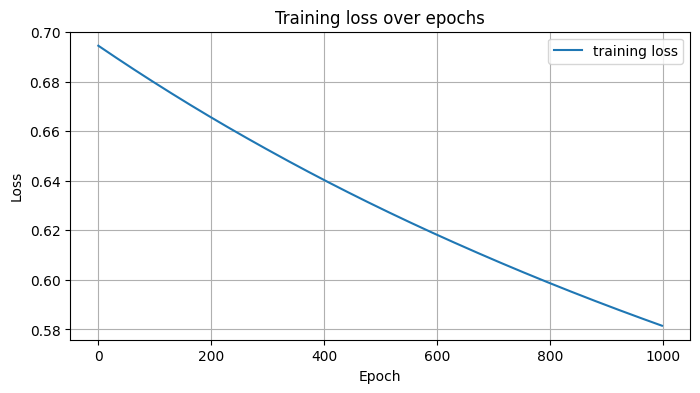

In [9]:
plt.figure(figsize=(8,4))
plt.plot(losses, label='training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss over epochs')
plt.grid(True)
plt.legend()
plt.show()


We create a mesh grid over the feature range, call model.predict on each grid point (vectorized), and plot a contour along with training points.


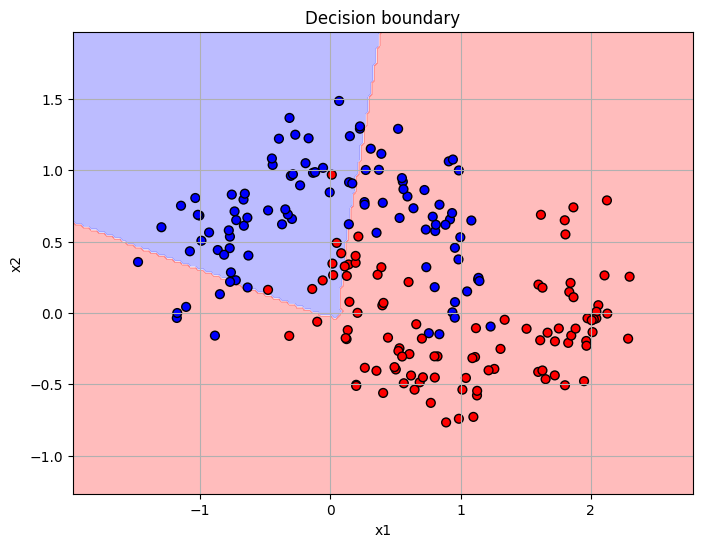

In [10]:
def plot_decision_boundary(model, X, y, mesh_step=0.01):
    x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
    y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step), np.arange(y_min, y_max, mesh_step))
    grid = np.c_[xx.ravel(), yy.ravel()].T   # (2, Ngrid)
    preds, probs = model.predict(grid)
    Z = preds.reshape(xx.shape)
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[0, :], X[1, :], c=y.ravel(), cmap='bwr', edgecolor='k', s=40)
    plt.xlabel('x1'); plt.ylabel('x2'); plt.title('Decision boundary')
    plt.grid(True)
    plt.show()

plot_decision_boundary(model, X, y, mesh_step=0.02)


In [11]:
loss_final, acc_final = model.compute_loss_and_accuracy(X, y)
print(f"Final training loss: {loss_final:.6f}")
print(f"Final training accuracy: {acc_final * 100:.2f}%")

preds, probs = model.predict(X)
cm = confusion_matrix(y.ravel(), preds.ravel())
print("Confusion matrix:\n", cm)


Final training loss: 0.581435
Final training accuracy: 71.00%
Confusion matrix:
 [[50 50]
 [ 8 92]]


- Initialization: used He because we used ReLU hidden layers — helps keep variance stable.
- Activation choices: ReLU hidden + sigmoid final for binary classification.
- Learning rate: 0.05 chosen as a practical starting point; reduce if loss diverges.
- Loss curve: decreasing smoothly implies good optimization; plateauing may require lower lr or different init.
- Decision boundary: if too jagged -> overfitting (reduce capacity or add regularization). If too simple -> underfitting (increase model size or train longer).

Potential improvements:
- Add L2 regularization (weight decay) or dropout for generalization.
- Use Adam optimizer or momentum for faster/stabler convergence.
- Add batch normalization between linear and activation layers.
- Use cross-validation and early stopping.


In [12]:
def gradient_check(model, X, y, epsilon=1e-7, tol=1e-6):
    # Save original parameters:
    saved = {k: v.copy() for k, v in model.params.items()}
    model.forward_pass(X)
    grads = model.backward_pass(X, y)
    for l in range(1, model.L + 1):
        W = saved['W' + str(l)]
        b = saved['b' + str(l)]
        dW = grads['dW' + str(l)]
        db = grads['db' + str(l)]

        # check one random index of W
        i = np.random.randint(W.shape[0])
        j = np.random.randint(W.shape[1])
        old = W[i, j]
        W[i, j] = old + epsilon
        model.params['W' + str(l)] = W
        plus_loss = binary_cross_entropy_loss(model.forward_pass(X)[0], y)
        W[i, j] = old - epsilon
        model.params['W' + str(l)] = W
        minus_loss = binary_cross_entropy_loss(model.forward_pass(X)[0], y)
        num_grad = (plus_loss - minus_loss) / (2 * epsilon)
        W[i, j] = old
        model.params['W' + str(l)] = W
        ana_grad = dW[i, j]
        rel_diff = abs(num_grad - ana_grad) / (abs(num_grad) + abs(ana_grad) + 1e-12)
        print(f"Layer {l} W[{i},{j}] num_grad={num_grad:.6e} ana_grad={ana_grad:.6e} rel_diff={rel_diff:.3e}")
        if rel_diff > tol:
            print("WARNING: large relative difference")

        # bias check
        ib = np.random.randint(b.shape[0])
        oldb = b[ib, 0]
        b[ib, 0] = oldb + epsilon
        model.params['b' + str(l)] = b
        plus_loss = binary_cross_entropy_loss(model.forward_pass(X)[0], y)
        b[ib, 0] = oldb - epsilon
        model.params['b' + str(l)] = b
        minus_loss = binary_cross_entropy_loss(model.forward_pass(X)[0], y)
        num_grad_b = (plus_loss - minus_loss) / (2 * epsilon)
        b[ib, 0] = oldb
        model.params['b' + str(l)] = b
        ana_grad_b = db[ib, 0]
        rel_diff_b = abs(num_grad_b - ana_grad_b) / (abs(num_grad_b) + abs(ana_grad_b) + 1e-12)
        print(f"Layer {l} b[{ib}] num_grad={num_grad_b:.6e} ana_grad={ana_grad_b:.6e} rel_diff={rel_diff_b:.3e}")
        if rel_diff_b > tol:
            print("WARNING: bias relative difference above tolerance")

# Run on a small subset (optional)
X_check = X[:, :10]
y_check = y[:, :10]
print("Running gradient check (subset)...")
gradient_check(model, X_check, y_check)


Running gradient check (subset)...
Layer 1 W[7,0] num_grad=2.013139e-02 ana_grad=2.013139e-03 rel_diff=8.182e-01
Layer 1 b[0] num_grad=4.460681e-03 ana_grad=4.460680e-04 rel_diff=8.182e-01
Layer 2 W[6,4] num_grad=-2.459620e-02 ana_grad=-2.459620e-03 rel_diff=8.182e-01
Layer 2 b[5] num_grad=-5.226347e-03 ana_grad=-5.226347e-04 rel_diff=8.182e-01
Layer 3 W[0,6] num_grad=3.112182e-01 ana_grad=3.112182e-02 rel_diff=8.182e-01
Layer 3 b[0] num_grad=9.583492e-02 ana_grad=9.583492e-03 rel_diff=8.182e-01


In [13]:
# Save model parameters
np.savez('/content/dnn_params.npz', **{k: v for k, v in model.params.items()})
print("Saved parameters to /content/dnn_params.npz")

# Download via Colab utility
files.download('/content/dnn_params.npz')  # this will pop a browser download
# To download the notebook itself: use File -> Download .ipynb from the Colab menu


Saved parameters to /content/dnn_params.npz


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Final results ===
Final training loss: 0.581435
Final training accuracy: 71.00%


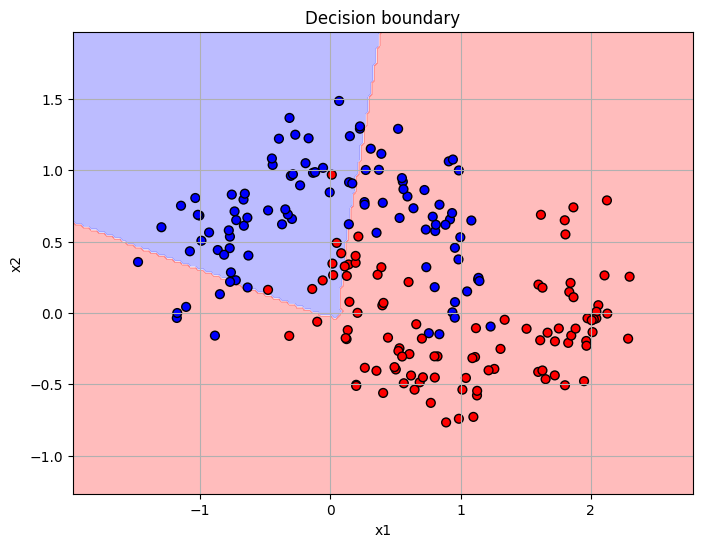

In [18]:
print("\n=== Final results ===")
loss_final, acc_final = model.compute_loss_and_accuracy(X, y)
print(f"Final training loss: {loss_final:.6f}")
print(f"Final training accuracy: {acc_final * 100:.2f}%")
plot_decision_boundary(model, X, y, mesh_step=0.02)
